# A Definitive Look at KAN: Kolmogorov-Arnold Networks

In [1]:
from IPython.core.display import HTML

def load_css(filename):
    with open(filename, "r") as f:
        css = f.read()
    return HTML("<style>{}</style>".format(css))

load_css("style.css")

Recently there has been much hype surrounding Kolmogorov-Arnold Networks. I was interested in this area as the authors proposed several attractive features of KAN as opposed to traditional MLPs: robustness to finetuning, parameter efficiency, better accuracy. When I tried getting into the center of KANs, I found it quite difficult to fully understand what exactly it was doing. Below is my attempt to organize my understanding of Kolmogorov-Arnold Networks, providing a definitive look at what truly is going on behind the scenes. I build up slowly from basis functions to B-spline interpolation. I then move on to the base KAN layer and training methodology used within the original KAN paper. As my research focuses on computer vision related tasks, I then look into Convolutional KANs and applications to toy datasets. Finally, I will take a dive into sparse KAN as a shameless little plug for my current pet project.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

# Chapter 1: A Single B-Spline

To put it simply, a B-spline is a way to construct a polynomial fit to some ground truth data. We use a set of basis functions which are constructed via predefined methods and splice these bases together to interpolate to the data. Mathematically, this is represented as 

\begin{equation}
\mathbf{P}(t) = \sum_{i=1}^{n+1} N_{i,k}(t) \mathbf{P}_i, \quad t_{\min} \leq t < t_{\max} \tag{1}
\end{equation}

where $\mathbf{P}_i, 1 \leq i \leq {n+1}$ are the control (ground truth) points. Notice that with $\mathbf{n}$ control points, we have $\mathbf{n}$ basis functions.


## Define a Ground Truth Function

To illustrate a interpolation of a single B-spline, let us define a ground truth function. with four ground truth points. We will be using these ground truth points to fit a B-spline that mimics the ground truth function.

In [5]:
np.random.seed(0)
x = np.array([0, 1, 2, 3])
y = np.array([-3, 1, 0.5, 1])
coeffs = np.polyfit(x, y, 3)
polynomial = np.poly1d(coeffs)
print(f"Ground Truth Function: P(x) = {coeffs[0]:.3f}x^3 + {coeffs[1]:.3f}x^2 + {coeffs[2]:.3f}x + {coeffs[3]:.3f}")

Ground Truth Function: P(x) = 0.917x^3 + -5.000x^2 + 8.083x + -3.000


Let's plot the ground truth function with the ground truth points that are known to us.

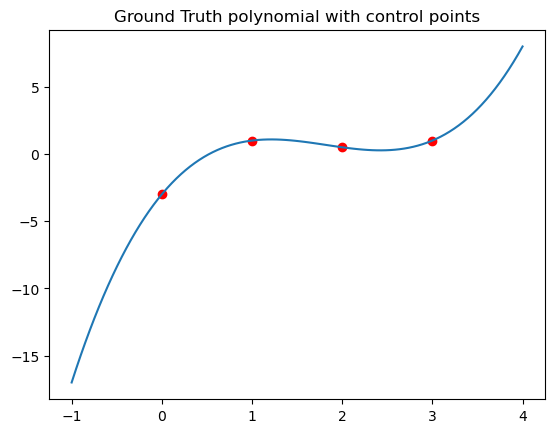

In [6]:
plot_x = np.linspace(-1, 4, 100)
plot_y = polynomial(plot_x)
plt.plot(plot_x, plot_y)
plt.scatter(x, y, c='r')
plt.title('Ground Truth polynomial with control points');

## Define B-Splines

Let's now define the core objective of a B-spline. We would like to find an order $\mathbf{k+1}$ spline within the bounds of [0, 3] that successfully fit our four ground truth points. Notice in the plot above that our four points divide the polynomial into five segments. We would like each segment to be degree $\mathbf{k}$. The way we find the spline is by construction. First, the basis functions are specified via this equation: 

\begin{equation}
N_{i,1}(t) = 
\begin{cases} 
1, & t_i \leq t < t_{i+1} \\
0, & \text{otherwise}
\end{cases}
\end{equation}



\begin{equation}
N_{i,k}(t) = \frac{t - t_i}{t_{i+k-1} - t_i} N_{i,k-1}(t) + \frac{t_{i+k} - t}{t_{i+k} - t_{i+1}} N_{i+1,k-1}(t)
\end{equation}


From equation ($1$), as construct the final B-spline as a linear combination of the basis functions, where the weights are equal to the target value of ground truth points. 

In the equation, $\mathbf{i}$ indicates the index of the basis function and $\mathbf{k}$ indicates the order. $\mathbf{t}_{i}s$ are the control points. At this point, it is also useful to mention that a B-spline of order $\mathbf{k}$ is $\mathbf{C}^{k-2}$ continuous. 

In [7]:
def b_spline(knots, k):
    def N_i_1(i, t):
        return t >= knots[i] and t < knots[i+1]

    def N_i_k(i, k, t):
        if k == 1:
            return N_i_1(i, t)
            
        return (t - knots[i]) / (knots[i + k - 1] - knots[i]) * N_i_k(i, k-1, t) + (knots[i + k] - t) / (knots[i + k] - knots[i + 1]) * N_i_k(i+1, k-1, t)

    def base_func(k):
        def base_func_helper(x):
            
            if isinstance(x, np.ndarray):
                if k == 1:
                    return np.array([[N_i_1(i, xitem) for xitem in x] for i in range(len(knots) - k)])
                else:
                    return np.array([[N_i_k(i, k, xitem) for xitem in x] for i in range(len(knots) - k)])

            else:
                if k == 1:
                    return np.array([N_i_1(i, x) for i in range(len(knots) - k)])
                else:
                    return np.array([N_i_k(i, k, x) for i in range(len(knots) - k)])
                    
        return base_func_helper
        
    return base_func(k)

In the below cell, we define the range of our spline. Because we have 4 control points, we have 3 intervals that we need to fit. This means we have 3 basis functions we need to define. Also note that on the edges we have 2 more basis functions that we want to define. Therefore, we will have $\mathbf{n + 2 * k = 3 + 2 * 1 = 5}$ basis functions. Since each degree 0 basis function spans 2 points, we will have a total of $\mathbf{2 + 5 - 1 = 6}$ grid points.

In [8]:
k = 1
grid_start = 0
grid_end = 3
grid_size=3

In [9]:
grid = np.arange(-k, grid_size + k + 1) + grid_start
print(f"this is the original grid: {grid}")

this is the original grid: [-1  0  1  2  3  4]


In [10]:
plot_x = np.linspace(grid_start - 1, grid_end + 1, 100)
colors = ['r', 'b', 'g', 'c', 'm', 'y', 'k']

Let's visualize the order 1 basis functions for our B-spline. Order 1 means degree 0, or the constant functions. Notice that each basis function takes on the value of 1 within their specified interval, and are otherwise 0.

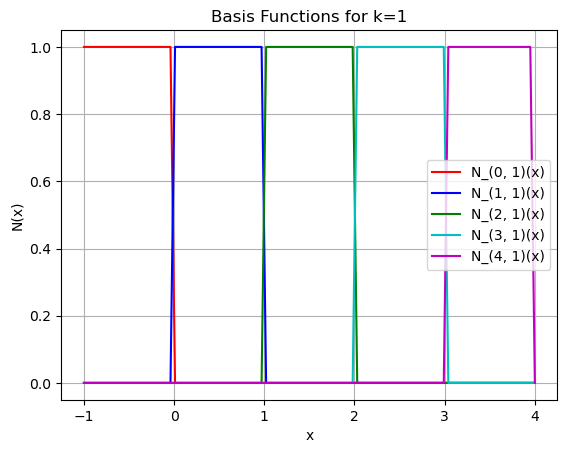

In [11]:
k=1
plot_y = b_spline(grid, k)(plot_x)
for i in range(len(grid) - k):
    plt.plot(plot_x, plot_y[i], c=colors[i], label=f'N_({i}, {k})(x)')
    plt.xlabel('x')
    plt.ylabel('N(x)')
    plt.grid(True)
    plt.legend()
plt.title(f"Basis Functions for k={k}")
plt.show();

In fact, we can visualize the $\mathbf{k=2}$ and $\mathbf{k=3}$ basis functions for our B-spline as well!

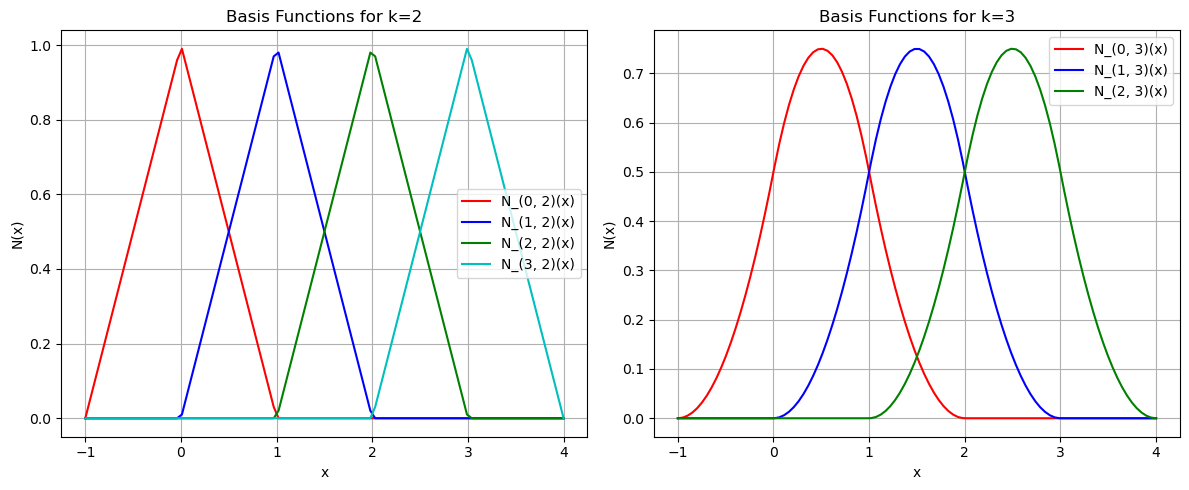

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
for k in range(2, 4):
    plot_y = b_spline(grid, k)(plot_x)
    
    # Use the appropriate axis for each plot
    ax = axes[k - 2]
    
    for i in range(len(grid) - k):
        ax.plot(plot_x, plot_y[i], c=colors[i], label=f'N_({i}, {k})(x)')
        
    ax.set_xlabel('x')
    ax.set_ylabel('N(x)')
    ax.grid(True)
    ax.legend()
    ax.set_title(f"Basis Functions for k={k}")

# Adjust layout and show the figure with subplots
plt.tight_layout()
plt.show()

Observe that with 6 grid points, we have less basis functions for the higher degrees. This is because each basis function of degree $\mathbf{n}$ spans $\mathbf{n + 2}$ grid points. For $\mathbf{k = 2}$, $\mathbf{n = 1}$ so each basis function spans 3 grid points.

Notice that higher degree basis functions have nonzero values across a larger range of values. Because of this, notice that we have less higher order basis functions that are fully shown in our grid. Remember that for  $\mathbf{n}$ control points, we need $\mathbf{n}$ basis functions. We get more higher degree basis functions by extending our grid, which I will go into further below.

For now, let's go back to looking at $\mathbf{k=1}$ basis functions. We can construct an approximation using our ground truth targets as the weights.

\begin{equation}
\mathbf{P}(t) = \sum_{i=-1}^{4} N_{i,1}(t) \mathbf{y}_{i}, \quad t_{-1} \leq t < t_{4}
\end{equation}

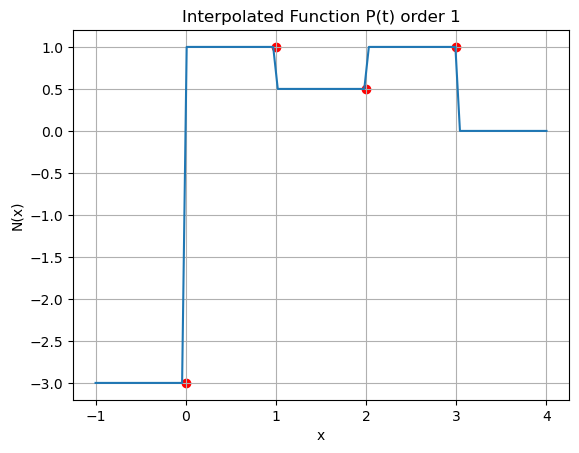

In [13]:
k=1
plot_y = b_spline(grid, k)(plot_x)[:-1]
plot_y = np.dot(y, plot_y)
plt.plot(plot_x, plot_y)
plt.xlabel('x')
plt.ylabel('N(x)')
plt.grid(True)
plt.title(f"Interpolated Function P(t) order {k}")
plt.scatter(x, y, c='r')
plt.show();

## Grid Extension

To create an approximation using higher degree basis functions, we need to extend our grid so that we have the same number of basis functions as we do control points. We do this by expanding the grid on both sides by $\mathbf{k}$, where $\mathbf{k}$ is our desired order B-spline. 

For $\mathbf{k=2}$, notice that to satisfy boundary conditions, we need to have one basis function that ends at the smallest control point and one basis function that starts at our largest control point. Since a basis function will span 3 grid points, we need to expand our original grid by $\mathbf{2 * k}$, $\mathbf{k}$ on each side.

In [14]:
k = 2
grid_start = 0
grid_end = 3
grid = np.arange(-k, grid_size + k + 1) + grid_start
#grid = np.arange(grid_start, grid_end)
print(f"this is the augmented grid for order {k}: {grid}")

this is the augmented grid for order 2: [-2 -1  0  1  2  3  4  5]


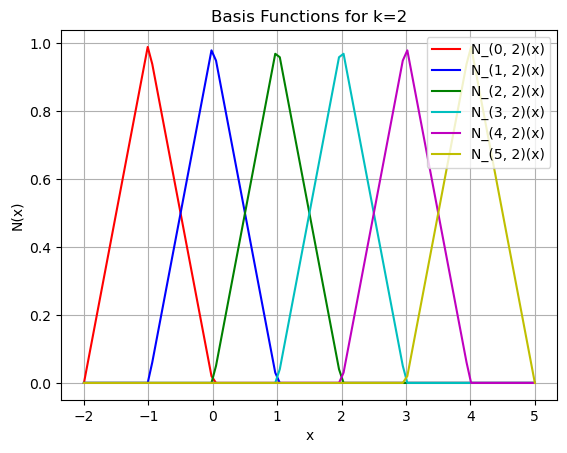

In [15]:
plot_x = np.linspace(grid[0], grid[-1], 100)
plot_y = b_spline(grid, k)(plot_x)
for i in range(len(plot_y)):
    plt.plot(plot_x, plot_y[i], c=colors[i], label=f'N_({i}, {k})(x)')
    plt.xlabel('x')
    plt.ylabel('N(x)')
    plt.grid(True)
    plt.legend()
plt.title(f"Basis Functions for k={k}")
plt.show();

In [16]:
plot_y.shape

(6, 100)

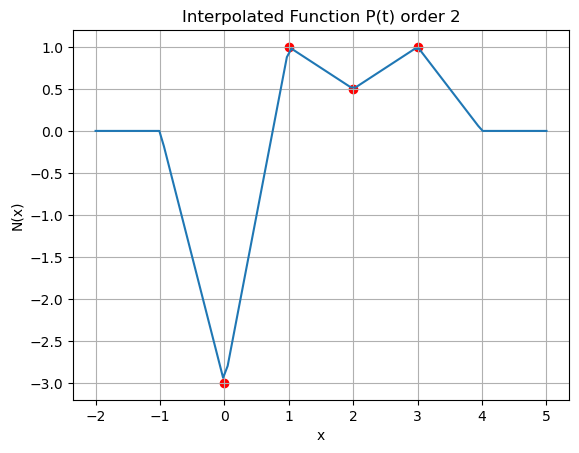

In [17]:
#t = len(plot_y) / 2
plot_y = np.dot(y, b_spline(grid, k)(plot_x)[1:-1])
plt.plot(plot_x, plot_y)
plt.xlabel('x')
plt.ylabel('N(x)')
plt.grid(True)
plt.title(f"Interpolated Function P(t) order {k}")
plt.scatter(x, y, c='r')
plt.show();

In [18]:
k = 3
grid_start = 0
grid_end = 3
#grid = np.arange(grid_start, grid_end)
grid = np.arange(-k, grid_size + k + 1) + grid_start
print(f"this is the augmented grid for order {k}: {grid}")

this is the augmented grid for order 3: [-3 -2 -1  0  1  2  3  4  5  6]


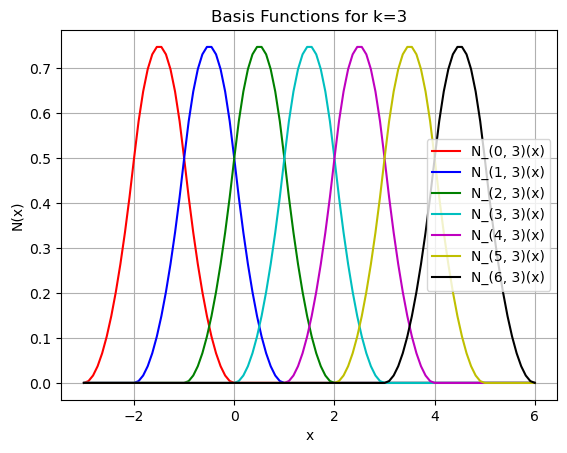

In [19]:
plot_x = np.linspace(grid[0], grid[-1], 100)
plot_y = b_spline(grid, k)(plot_x)
for i in range(len(plot_y)):
    plt.plot(plot_x, plot_y[i], c=colors[i], label=f'N_({i}, {k})(x)')
    plt.xlabel('x')
    plt.ylabel('N(x)')
    plt.grid(True)
    plt.legend()
plt.title(f"Basis Functions for k={k}")
plt.show();

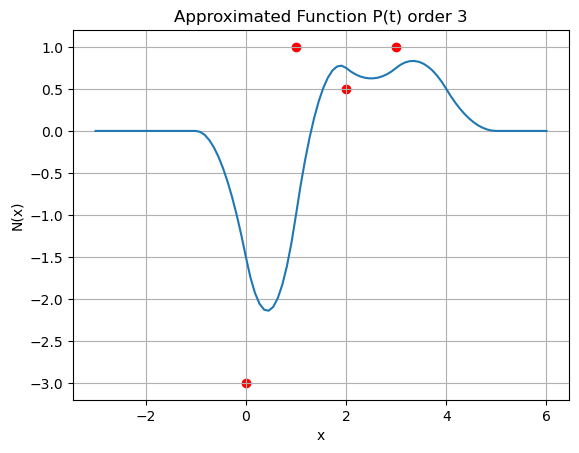

In [20]:
plot_y = np.dot(y, b_spline(grid, k)(plot_x)[2:-1])
plt.plot(plot_x, plot_y)
plt.xlabel('x')
plt.ylabel('N(x)')
plt.grid(True)
plt.title(f"Approximated Function P(t) order {k}")
plt.scatter(x, y, c='r')
plt.show();

Notice that as we increase the degree of our piecewise polynomials, our B-spline does not actually interpolate the ground truth points! This is a key characteristic of B-splines: exact interpolation is not the main goal, the main goal is to get a spline that is as smooth as possible. We call the above B-spline approximation.

What if we want a B-spline that does interpolate the points? We would need to solve system of linear equations to find proper weights instead of using the target of the ground truth.

## Approximation

Notice in the previous examples I have been specifying a grid with width of exactly 1. In our range of [0, 3] we would thus have exactly four control points at 0, 1, 2, and 3 respectively. We did this because we had four known ground truth points at 0, 1, 2, and 3. However, our next step is to step away from using the ground truth points as weights and find our weights via solving least-squares. Because of this, we can specify arbitrary number of basis functions within the range [0, 3]. All we need to do is scale the grid. Let's try using 5 intervals.

In [21]:
k = 3 # the order spline we want
grid_size = 5 # number of control points
grid_start = 0 # start of range for our interpolation
grid_end = 3 # end of range for our interpolation
h = (grid_end - grid_start) / grid_size
augmented_grid = np.arange(-k, grid_size + k + 1) * h + grid_start
print(f"grid after augmenting the endpoints: {augmented_grid}")

grid after augmenting the endpoints: [-1.8 -1.2 -0.6  0.   0.6  1.2  1.8  2.4  3.   3.6  4.2  4.8]


When we specify a grid_size of 5, we want to interpolate five intervals between our range [0, 3]. Five intervals means 6 grid points. Additionally, we need to interpolate the basis function that ends at our leftmost point 0 and the basis function that starts at our rightmost point 3. Since a basis function of order 3 spans 4 grid points, we need to expand our grid by $\mathbf{2*k=6}$ points, $\mathbf{3}$ on each side. This gives us a total of 12 grid points.

From another perspective, we want to interpolate five intervals and at any interval there are $\mathbf{k=3}$ nonzero basis functions. This gives us $\mathbf{3 + 5 - 1 = 7}$ nonzero basis functions in our range [0, 3]. We add two basis functions, one on either end to interpolate the boundary, bringing our total to 9 basis functions. Each basis function spans k + 1 grid points, which leads us to $\mathbf{4 + (9-1) = 12}$ grid points.

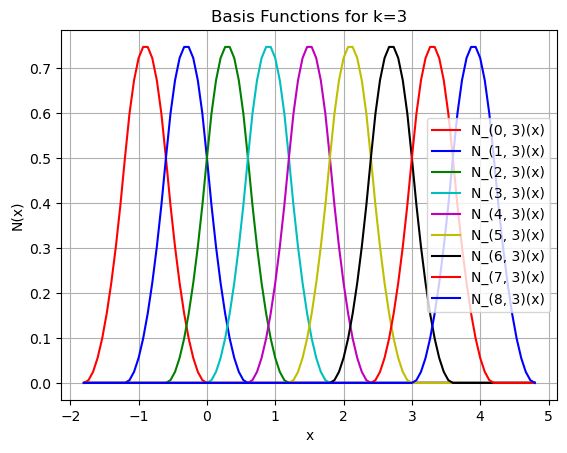

In [22]:
plot_x = np.linspace(augmented_grid[0], augmented_grid[-1], 100)
colors = ['r', 'b', 'g', 'c', 'm', 'y', 'k'] * 2
plot_y = b_spline(augmented_grid, k)(plot_x)
for i in range(len(augmented_grid) - k):
    plt.plot(plot_x, plot_y[i], c=colors[i], label=f'N_({i}, {k})(x)')
    plt.xlabel('x')
    plt.ylabel('N(x)')
    plt.grid(True)
    plt.legend()
plt.title(f"Basis Functions for k={k}")
plt.show();

If we zoom in on our desired range [0, 3], notice only 7 basis functions are nonzero within this range.

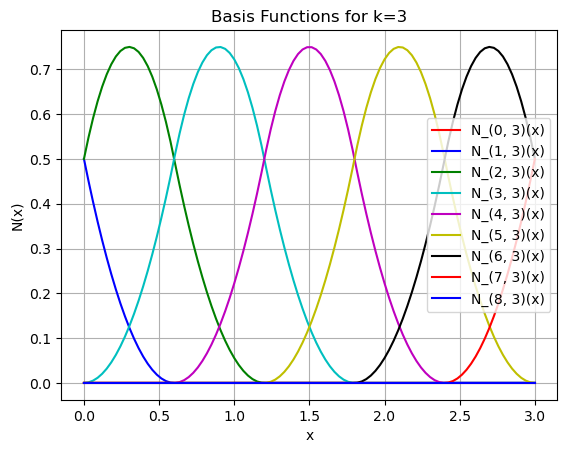

In [23]:
plot_x = np.linspace(0, 3, 100)
colors = ['r', 'b', 'g', 'c', 'm', 'y', 'k'] * 2
plot_y = b_spline(augmented_grid, k)(plot_x)
for i in range(len(augmented_grid) - k):
    plt.plot(plot_x, plot_y[i], c=colors[i], label=f'N_({i}, {k})(x)')
    plt.xlabel('x')
    plt.ylabel('N(x)')
    plt.grid(True)
    plt.legend()
plt.title(f"Basis Functions for k={k}")
plt.show();

In each interval, we will have k number of nonzero basis functions. This means that for G intervals, we will have k + (G - 1) basis functions.

Now is a good time to fully define some numbers and parameters. 

- For $\mathbf{k}$ order spline with $\mathbf{n}$ control points, we have $\mathbf{n-1}$ intervals to interpolate
- For each interval, there are $\mathbf{k}$ nonzero basis functions.
- There are a total of $\mathbf{k + (n-1) - 1 = k + n - 2}$ nonzero basis functions on the range.
- Each basis function of in an order $\mathbf{k}$ spline spans $\mathbf{k+1}$ grid points.
- Thus, $\mathbf{k+1 + (k + n - 2) - 1 = 2 * k + n - 2}$ grid points are needed to fully define all basis functions.

However, this is not enough if we want to interpolate the boundary.

- To interpolate the boundary, we add one more basis function on either side of the range, bringing the total to $\mathbf{k + n}$ basis functions.
- The total grid vector length is therefore $\mathbf{k + 1 + (k + n) - 1 = 2 * k + n}$

Please note that when we specify the grid size $\mathbf{g}$, we are specifying the number of intervals to interpolate, meaning that we would have $\mathbf{n = g + 1}$ control points.

Our objective in B-spline interpolation is to learn the $\mathbf{k+n}$ weights that are associated with the basis functions.

## Let's Fit our B-Spline!

In [32]:
bspline = b_spline(augmented_grid, k)

In [33]:
def residuals(params, x, y):
    return y - np.dot(params, bspline(x))

In [34]:
initial_guess = np.zeros(grid_size+k+1)
fitted_params = scipy.optimize.least_squares(residuals, initial_guess, args = (x[:-1], y[:-1])).x

In [35]:
fitted_params

array([-4.95989237e-17, -3.05492450e+00, -2.94507547e+00,  1.42803748e+00,
        5.95147019e-01,  5.06190326e-01,  3.89377189e-02,  0.00000000e+00,
        0.00000000e+00])

A B-spline is fully defined by k + n parameters, which in this case is 3 + (5+1) = 9

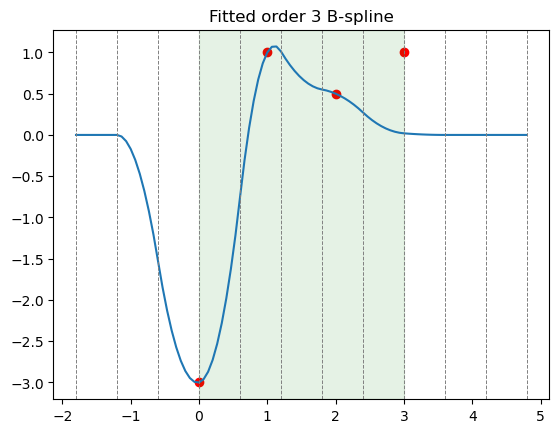

In [36]:
plot_x = np.linspace(augmented_grid[0], augmented_grid[-1], 100)
plot_y = np.dot(fitted_params, bspline(plot_x))
plt.plot(plot_x, plot_y)
plt.scatter(x, y, c='r')

for vl in augmented_grid:
    plt.axvline(x=vl, color='gray', linestyle='--', linewidth=0.7)

plt.autoscale(False)
plt.fill_betweenx(y=plt.ylim(), x1=0, x2=3, color='green', alpha=0.1)
plt.title(f'Fitted order {k} B-spline');

## Let's get a more fine grained spline!

In [37]:
k=3
grid_size=7
h = (grid_end - grid_start) / grid_size
augmented_grid_fine = np.arange(-k, grid_size + k + 1) * h + grid_start
print(f"grid after augmenting the endpoints: {augmented_grid_fine}")
fine_bspline = b_spline(augmented_grid_fine, k)

grid after augmenting the endpoints: [-1.28571429 -0.85714286 -0.42857143  0.          0.42857143  0.85714286
  1.28571429  1.71428571  2.14285714  2.57142857  3.          3.42857143
  3.85714286  4.28571429]


In [38]:
def grid_update_residuals(params, x, y):
    return np.dot(fitted_params, bspline(x)) - np.dot(params, fine_bspline(x))

In [39]:
initial_guess = np.zeros(grid_size+k+1)
fitted_params = scipy.optimize.least_squares(grid_update_residuals, initial_guess, args = (x[:-1], y[:-1])).x

In [40]:
fitted_params

array([-5.20333603e-19, -2.99999999e+00, -2.99999999e+00,  3.86067351e-01,
        1.25471888e+00,  1.44385026e-01,  6.22286460e-01,  1.91472756e-01,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00])

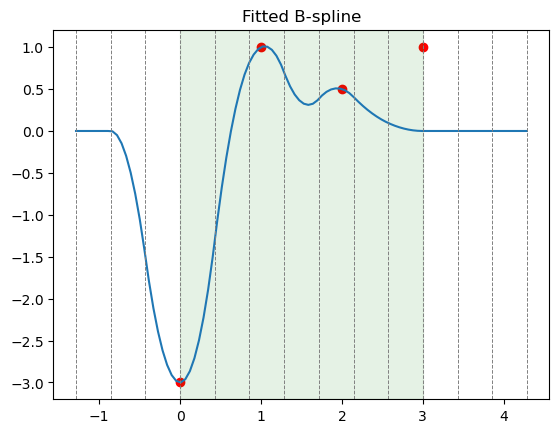

In [41]:
plot_x = np.linspace(augmented_grid_fine[0], augmented_grid_fine[-1], 100)
plot_y = np.dot(fitted_params, fine_bspline(plot_x))
plt.plot(plot_x, plot_y)
plt.scatter(x, y, c='r')

for vl in augmented_grid_fine:
    plt.axvline(x=vl, color='gray', linestyle='--', linewidth=0.7)

plt.autoscale(False)
plt.fill_betweenx(y=plt.ylim(), x1=0, x2=3, color='green', alpha=0.1)

plt.title('Fitted B-spline');

## Continue Fitting Fine Grained Spline

In [42]:
def residuals(params, x, y):
    return y - np.dot(params, fine_bspline(x))

In [43]:
final_params = scipy.optimize.least_squares(residuals, fitted_params, args = (x, y)).x

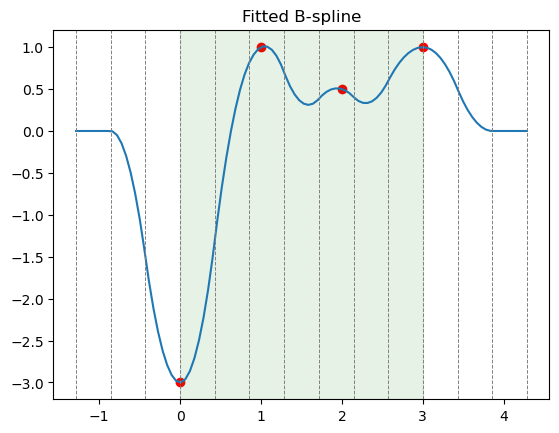

In [44]:
plot_x = np.linspace(augmented_grid_fine[0], augmented_grid_fine[-1], 100)
plot_y = np.dot(final_params, fine_bspline(plot_x))
plt.plot(plot_x, plot_y)
plt.scatter(x, y, c='r')

for vl in augmented_grid_fine:
    plt.axvline(x=vl, color='gray', linestyle='--', linewidth=0.7)

plt.autoscale(False)
plt.fill_betweenx(y=plt.ylim(), x1=0, x2=3, color='green', alpha=0.1)

plt.title('Fitted B-spline');

# Chapter 2: The Kolmogorov-Arnold Network

In [24]:
import tensorflow as tf
mse_loss = tf.keras.losses.MeanSquaredError()

In [25]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.boston_housing.load_data()

In [26]:
# Find the min and max for each dimension (column)
min_vals = np.min(x_train, axis=0)
max_vals = np.max(x_train, axis=0)

# Apply the normalization
normalized_data = (x_train - min_vals) / (max_vals - min_vals)

In [27]:
x_train = normalized_data

In [28]:
# Find the min and max for each dimension (column)
min_vals = np.min(y_train, axis=0)
max_vals = np.max(y_train, axis=0)

# Apply the normalization
normalized_data = (y_train - min_vals) / (max_vals - min_vals)

In [29]:
y_train = normalized_data

In [51]:
class b_spline_layer:
    def __init__(self, grid_size, order, inp_dim):
        self.k = order
        self.grid_size = grid_size
        self.grid_range = [-1, 1]
        h = (self.grid_range[1] - self.grid_range[0]) / self.grid_size
        self.grid = np.arange(-k, grid_size + k + 1) * h + self.grid_range[0]
        self.act_func = [] # all of the b_splines
        
        for i in range(inp_dim):
            self.act_func.append(b_spline(self.grid, order))

        self.spline_weights = np.ones((inp_dim, order + grid_size + 1))
        self.base_weights = np.ones((inp_dim, 1))
        self.inp_dim = inp_dim

        self.act2_func = b_spline(self.grid, order)
        self.spline2_weight = np.ones((order + grid_size + 1))
        self.base2_weight = np.ones(1)

    def set_weights(self, spline, base, spline2, base2):
        self.spline_weights = spline
        self.base_weights = base
        self.spline2_weight = spline2
        self.base2_weight = base2

    def silu(self, x):
        return x / (1 + np.exp(-x))

    def forward(self, x):
        batch_result = []
        for j in range(len(x)):
        
            result = []
            for i in range(self.inp_dim):
                result.append(np.dot(self.spline_weights[i], self.act_func[i](x[j][i])) + self.base_weights[i] * self.silu(x[j][i])) # we are passing each dimension of x through a different b-spline
    
            new_x = np.sum(result)
            batch_result.append( np.dot(self.spline2_weight, self.act2_func(np.sum(new_x))) + self.base2_weight * self.silu(new_x) )

        return np.array(batch_result)
        

In [52]:
layer = b_spline_layer(grid_size = 3, order = 3, inp_dim = len(x_train[0]))

In [53]:
def parse_params(layer, params):
    start = 0
    end = layer.inp_dim * (layer.k + layer.grid_size + 1)
    sw = params[start:end].reshape(layer.inp_dim, (layer.k + layer.grid_size + 1))

    start = end
    end += layer.inp_dim
    
    bw = params[start:end].reshape(layer.inp_dim, 1)

    start = end
    end += layer.k + layer.grid_size + 1

    sw2 = params[start:end]

    start = end
    end += 1

    bw2 = params[start:end]
    layer.set_weights(sw, bw, sw2, bw2)

def objective_function_builder(x, y):
    

    def layer_residuals(params):
        parse_params(layer, params)
        #print("mse_loss", mse_loss(y, layer.forward(x).squeeze()).numpy())
        #print("np_mean", np.mean((y-layer.forward(x).squeeze()) ** 2))
        return np.mean((y - layer.forward(x).squeeze()) ** 2)

    return layer_residuals

In [54]:
layer_params = np.ones(layer.inp_dim * (layer.k + layer.grid_size + 1) + layer.inp_dim + layer.k + layer.grid_size + 1 + 1)
layer_params = scipy.optimize.minimize(objective_function_builder(x_train[:100], y_train[:100]), layer_params,
                                                                  options={'maxiter':10}).x

In [55]:
parse_params(layer, layer_params)

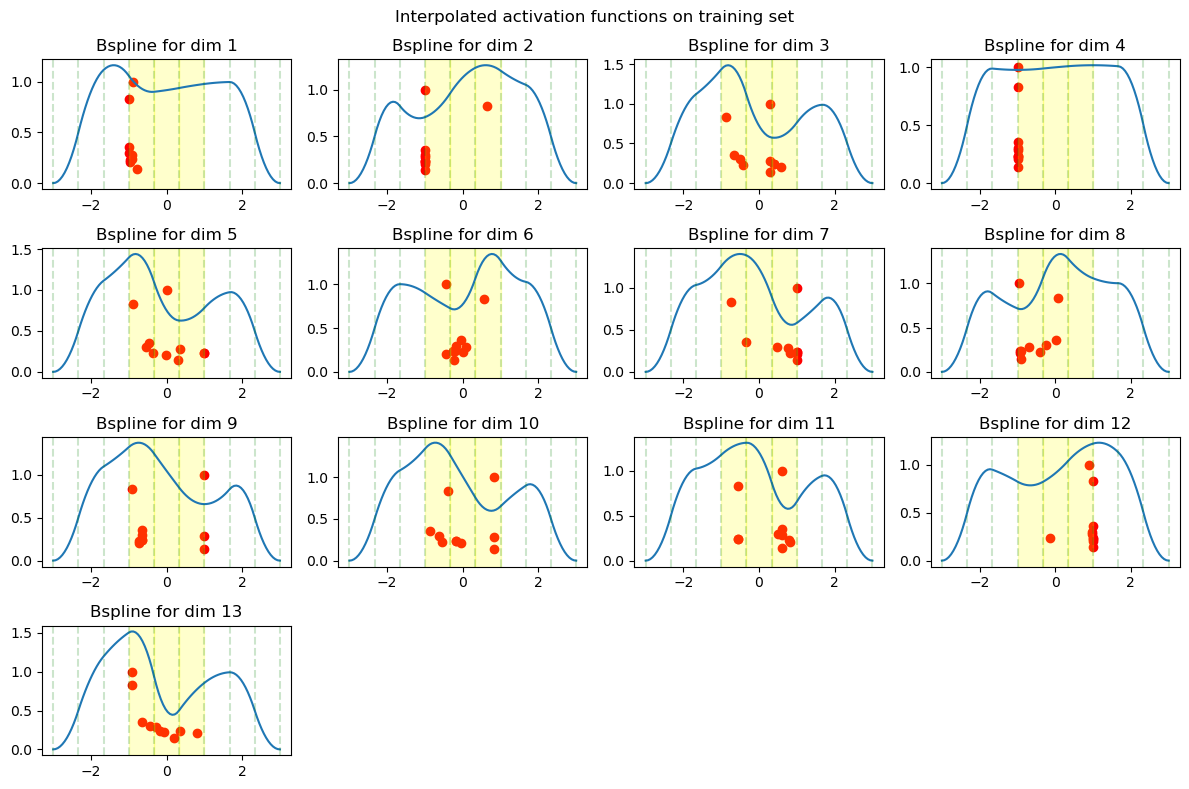

In [56]:
plot_x = np.linspace(layer.grid[0], layer.grid[-1], 100)
num_plots = len(layer.act_func)

# Determine the grid size, you can adjust rows and cols depending on how you want to layout the grid
rows = int(np.ceil(np.sqrt(num_plots)))
cols = int(np.ceil(num_plots / rows))

fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
axes = axes.flatten() 


for i in range(len(layer.act_func)):
    plot_y = np.dot(layer.spline_weights[i], layer.act_func[i](plot_x))

    axes[i].plot(plot_x, plot_y)
    axes[i].scatter(x_train[:10, i], y_train[:10], c='r')
    for x in layer.grid:
        axes[i].axvline(x, c='g', linestyle='--', alpha=0.2)
    
    axes[i].axvspan(layer.grid[3], layer.grid[4], color='yellow', alpha=0.2)
    axes[i].axvspan(layer.grid[4], layer.grid[5], color='yellow', alpha=0.2)
    axes[i].axvspan(layer.grid[5], layer.grid[6], color='yellow', alpha=0.2)
    axes[i].set_title(f'Bspline for dim {i+1}')

    
for j in range(i + 1, rows * cols):
    axes[j].axis('off')

fig.suptitle('Interpolated activation functions on training set')
plt.tight_layout()
plt.show()

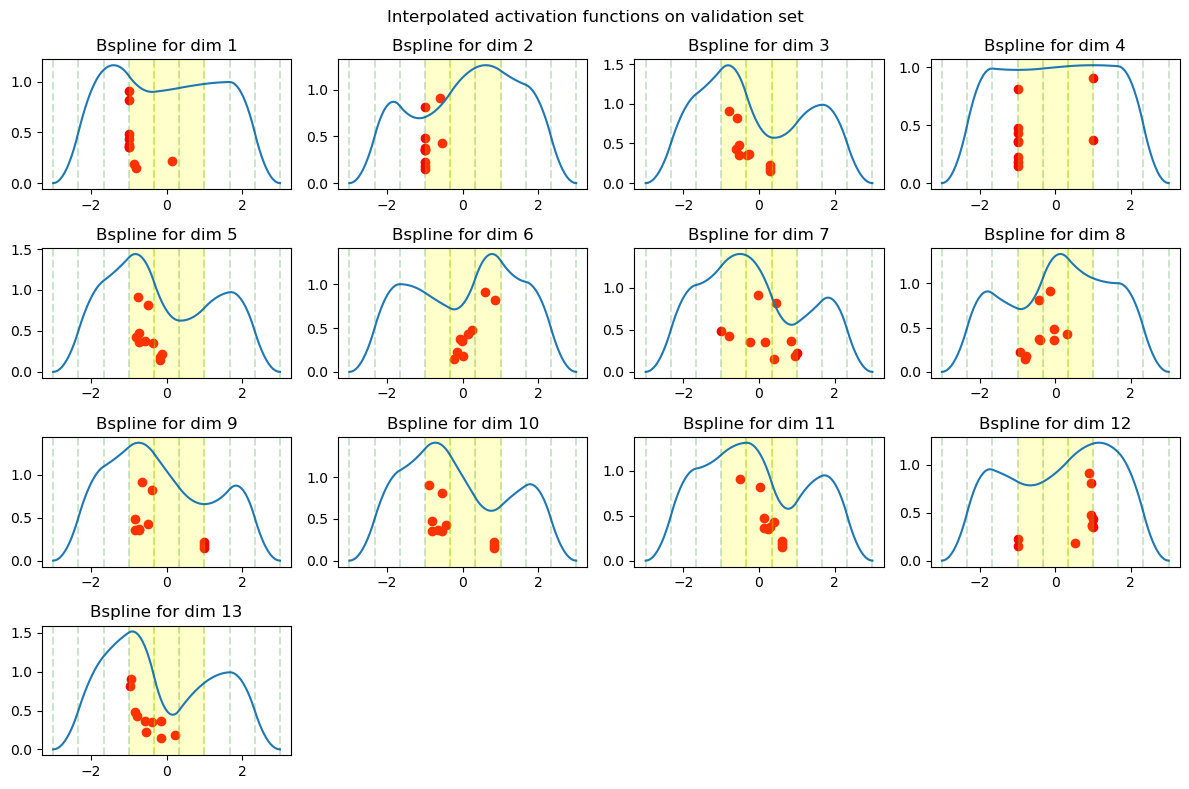

In [57]:
plot_x = np.linspace(layer.grid[0], layer.grid[-1], 100)
num_plots = len(layer.act_func)

# Determine the grid size, you can adjust rows and cols depending on how you want to layout the grid
rows = int(np.ceil(np.sqrt(num_plots)))
cols = int(np.ceil(num_plots / rows))

fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
axes = axes.flatten() 


for i in range(len(layer.act_func)):
    plot_y = np.dot(layer.spline_weights[i], layer.act_func[i](plot_x))

    axes[i].plot(plot_x, plot_y)
    axes[i].scatter(x_train[100:110, i], y_train[100:110], c='r')
    for x in layer.grid:
        axes[i].axvline(x, c='g', linestyle='--', alpha=0.2)
    
    axes[i].axvspan(layer.grid[3], layer.grid[4], color='yellow', alpha=0.2)
    axes[i].axvspan(layer.grid[4], layer.grid[5], color='yellow', alpha=0.2)
    axes[i].axvspan(layer.grid[5], layer.grid[6], color='yellow', alpha=0.2)
    axes[i].set_title(f'Bspline for dim {i+1}')

    
for j in range(i + 1, rows * cols):
    axes[j].axis('off')

fig.suptitle('Interpolated activation functions on validation set')
plt.tight_layout()
plt.show()

In [58]:
plot_2y = np.dot(layer.spline2_weight, layer.act2_func(plot_y))

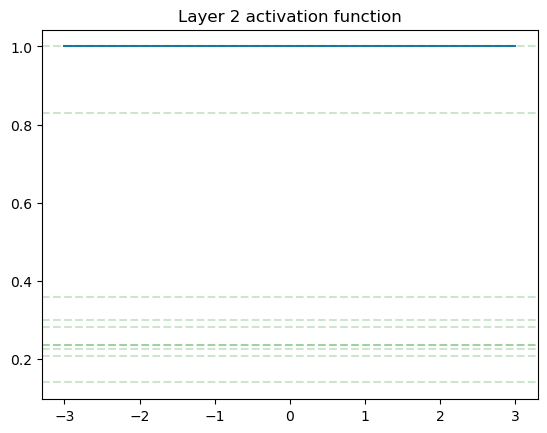

In [59]:
plt.plot(plot_x, plot_2y)
for yline in y_train[:10]:
    plt.axhline(yline, c='g', linestyle='--', alpha=0.2)
plt.title('Layer 2 activation function');

In [60]:
train_loss = mse_loss(y_train[:100], layer.forward(x_train[:100]).squeeze())
val_loss = mse_loss(y_train[100:], layer.forward(x_train[100:]).squeeze())

In [61]:
print(f"The MSE Loss on training set is {train_loss}. The MSE Loss on validation set is {val_loss}.")

The MSE Loss on training set is 0.03272057697176933. The MSE Loss on validation set is 0.0343267023563385.


## Regularization

It should be quite evident now that by itself, a Bspline of order $\mathbf{k}$ and $\mathbf{n}$ control points has $\mathbf{k+n}$ parameters, whereas a regular MLP connection has 1 parameter. Do encourage sparsity in a Kolmogorov-Arnold Network, the authors add a regularization term that limits the number of activation functions. Below, we try to fit a KAN layer with regularization.

In the KAN Literature, the L1 norm of an activation function is defined to be the average magnitude over its inputs.

In [319]:
"""
def l1_norm(func, x):
    print(np.dot(layer.spline_weights[i], func(x)).shape)
    return np.sum(np.abs(np.dot(layer.spline_weights[i], func(x)))) / len(x)

def l1_layer_norm(layer, x):
    results = np.array([l1_norm(layer.act_func[i], x[:,i], i) for i in range(len(layer.act_func))])
    return np.sum(results)

"""
def layer_entropy(layer, x):
    act_func_norms = []
    for i in range(len(layer.act_func)):
        act_func_norms.append(np.sum(np.abs(np.dot(layer.spline_weights[i], layer.act_func[i](x[:,i])))) / len(x))

    act_func_norms = np.array(act_func_norms)
    layer_norm = np.sum(act_func_norms)

    layer_entropy = -1 * np.sum((act_func_norms / layer_norm) * np.log((act_func_norms / layer_norm)))

    return layer_norm, layer_entropy

In [320]:
def objective_function_builder(x, y):
    

    def regularized_layer_residuals(params):

        parse_params(layer, params)
        l_norm, l_entropy = layer_entropy(layer, x)
        #print("regular loss term", np.sqrt(np.sum((y - layer.forward(x).squeeze()) ** 2)))
        #print("layer norm", l_norm)
        #print("layer_entropy", l_entropy)
        return np.sqrt(np.sum((y - layer.forward(x).squeeze()) ** 2)) + 0.01 * (l_norm + l_entropy)

    return regularized_layer_residuals

In [321]:
layer = b_spline_layer(grid_size = 3, order = 3, inp_dim = len(x_train[0]))

In [322]:
layer_params = np.ones(layer.inp_dim * (layer.k + layer.grid_size + 1) + layer.inp_dim + layer.k + layer.grid_size + 1 + 1)
layer_params = scipy.optimize.minimize(objective_function_builder(x_train[:100], y_train[:100]), 
                                       layer_params,
                                       options={'disp':True,
                                               'maxiter':10}).x

         Current function value: 1.541279
         Iterations: 10
         Function evaluations: 1921
         Gradient evaluations: 17


In [323]:
parse_params(layer, layer_params)

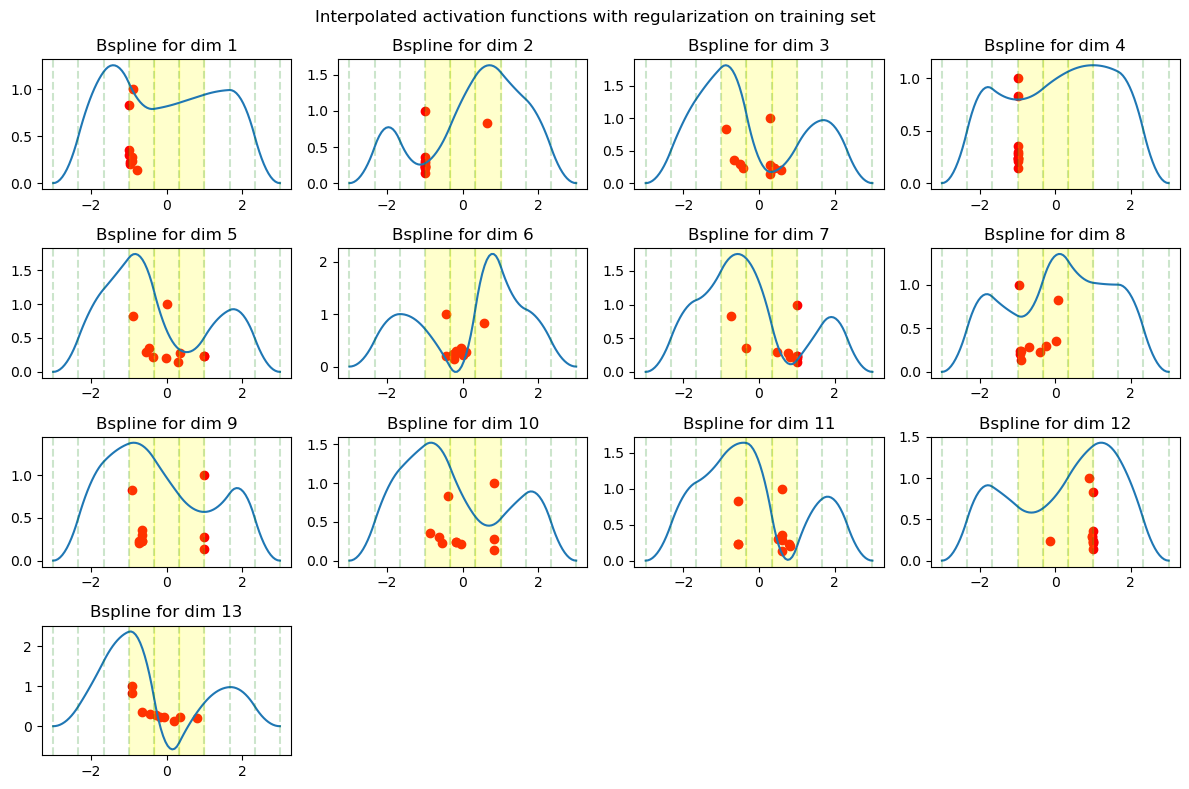

In [324]:
plot_x = np.linspace(layer.grid[0], layer.grid[-1], 100)
num_plots = len(layer.act_func)

# Determine the grid size, you can adjust rows and cols depending on how you want to layout the grid
rows = int(np.ceil(np.sqrt(num_plots)))
cols = int(np.ceil(num_plots / rows))

fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
axes = axes.flatten() 


for i in range(len(layer.act_func)):
    plot_y = np.dot(layer.spline_weights[i], layer.act_func[i](plot_x))

    axes[i].plot(plot_x, plot_y)
    axes[i].scatter(x_train[:10, i], y_train[:10], c='r')
    for x in layer.grid:
        axes[i].axvline(x, c='g', linestyle='--', alpha=0.2)
    
    axes[i].axvspan(layer.grid[3], layer.grid[4], color='yellow', alpha=0.2)
    axes[i].axvspan(layer.grid[4], layer.grid[5], color='yellow', alpha=0.2)
    axes[i].axvspan(layer.grid[5], layer.grid[6], color='yellow', alpha=0.2)
    axes[i].set_title(f'Bspline for dim {i+1}')

    
for j in range(i + 1, rows * cols):
    axes[j].axis('off')

fig.suptitle('Interpolated activation functions with regularization on training set')
plt.tight_layout()
plt.show()

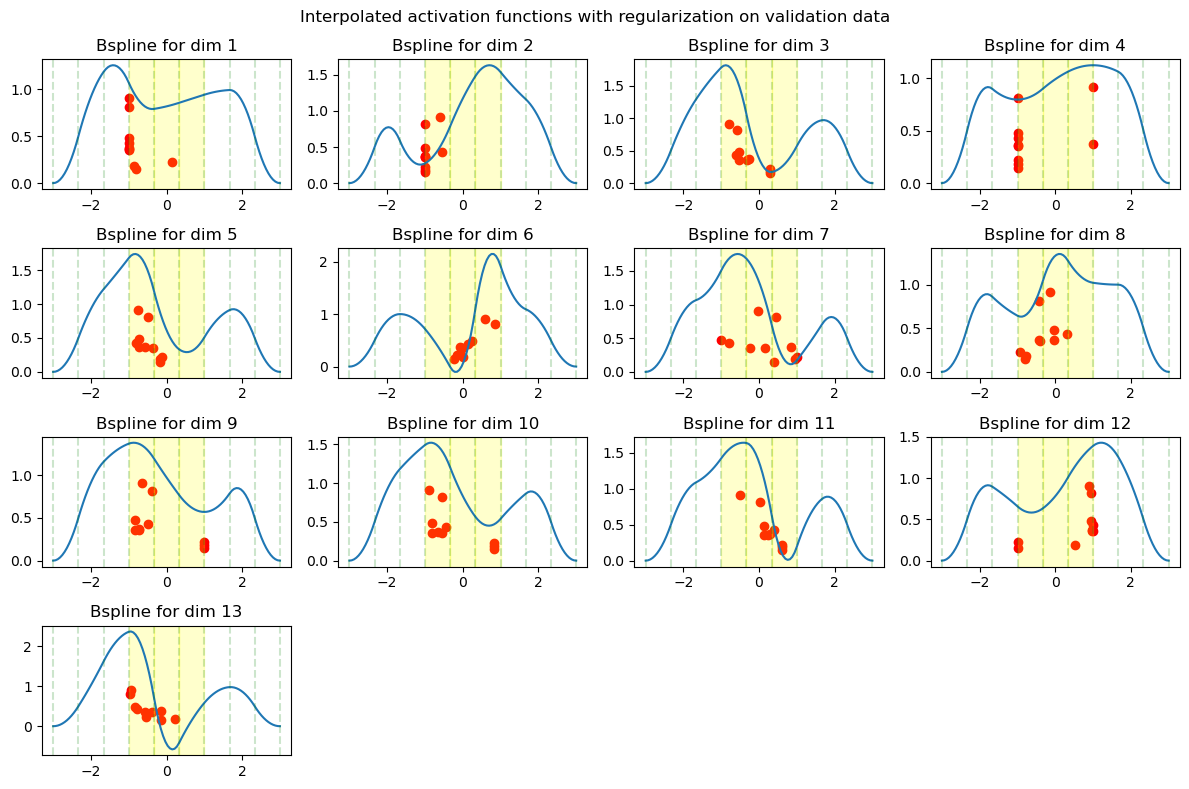

In [325]:
plot_x = np.linspace(layer.grid[0], layer.grid[-1], 100)
num_plots = len(layer.act_func)

# Determine the grid size, you can adjust rows and cols depending on how you want to layout the grid
rows = int(np.ceil(np.sqrt(num_plots)))
cols = int(np.ceil(num_plots / rows))

fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
axes = axes.flatten() 


for i in range(len(layer.act_func)):
    plot_y = np.dot(layer.spline_weights[i], layer.act_func[i](plot_x))

    axes[i].plot(plot_x, plot_y)
    axes[i].scatter(x_train[100:110, i], y_train[100:110], c='r')
    for x in layer.grid:
        axes[i].axvline(x, c='g', linestyle='--', alpha=0.2)
    
    axes[i].axvspan(layer.grid[3], layer.grid[4], color='yellow', alpha=0.2)
    axes[i].axvspan(layer.grid[4], layer.grid[5], color='yellow', alpha=0.2)
    axes[i].axvspan(layer.grid[5], layer.grid[6], color='yellow', alpha=0.2)
    axes[i].set_title(f'Bspline for dim {i+1}')

    
for j in range(i + 1, rows * cols):
    axes[j].axis('off')

fig.suptitle('Interpolated activation functions with regularization on validation data')
plt.tight_layout()
plt.show()

In [326]:
plot_2y = np.dot(layer.spline2_weight, layer.act2_func(plot_y))

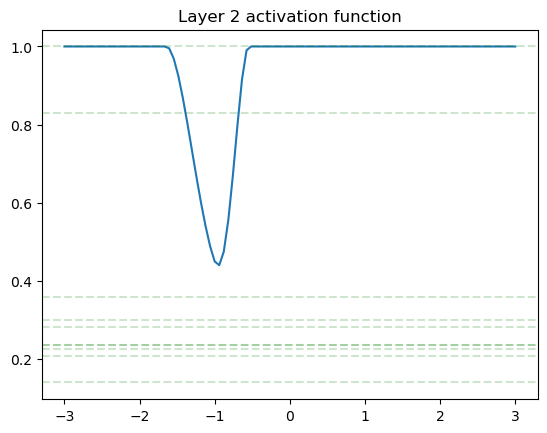

In [327]:
plt.plot(plot_x, plot_2y)
for yline in y_train[:10]:
    plt.axhline(yline, c='g', linestyle='--', alpha=0.2)
plt.title('Layer 2 activation function');

In [328]:
train_loss = mse_loss(y_train[:100], layer.forward(x_train[:100]).squeeze())
val_loss = mse_loss(y_train[100:], layer.forward(x_train[100:]).squeeze())
print(f"The MSE Loss on training set is {train_loss}. The MSE Loss on validation set is {val_loss}.")

The MSE Loss on training set is 0.019594168290495872. The MSE Loss on validation set is 0.02265910990536213.


## Activation Grouping

In [631]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [632]:
combined_weights = np.concatenate((layer.spline_weights, layer.base_weights), axis=1)

In [633]:
similarities = []
for i in range(len(combined_weights)):
    for j in range(len(combined_weights)):
        similarities.append(cosine_similarity(combined_weights[i], combined_weights[j]))

similarities = np.array(similarities).reshape((i + 1, j + 1))

In [634]:
theta = 0.95
num_nodes = len(layer.act_func)

In [635]:
significant = (similarities > 0.95) & (similarities != np.max(similarities-np.eye(num_nodes), axis=0)[:,np.newaxis])
largest = np.argmax(similarities-np.eye(num_nodes)*(1-theta), axis=0)[:,np.newaxis].squeeze()

In [637]:
from collections import deque, defaultdict
stack = deque()
stack.extend(range(num_nodes-1, -1, -1))

trace = []
sets = defaultdict(list)
visited = [False] * num_nodes

while len(stack) != 0:
    index = stack.pop()
    if not visited[index]:
        if index in trace:
            for item in trace:
                if not visited[item]:
                    sets[index].append(item)
                    visited[item] = True
            trace = []
        else:
            trace.append(index)

            for i in range(num_nodes):
                if significant[index][i]:
                    stack.append(i)
    
            stack.append(largest[index])    

In [663]:
sets

defaultdict(list,
            {3: [0, 3, 7],
             11: [11, 1],
             2: [2, 4],
             9: [9, 8],
             5: [5],
             6: [6, 10],
             12: [12]})

In [652]:
new_weights = combined_weights.copy()

In [654]:
for key in sets:
    print(new_weights[sets[key]])
    new_weights[sets[key]] = new_weights[key]
    print(new_weights[sets[key]])


[[1.         1.37210617 0.7694669  0.81307797 0.89992656 0.98518409
  1.         0.78639371]
 [1.         0.79587918 0.79587918 1.         1.12313145 1.12313145
  1.         1.18465462]
 [1.         0.72250601 0.56505994 1.50784972 1.0428608  0.99988438
  1.         1.12737138]]
[[1.         0.79587918 0.79587918 1.         1.12313145 1.12313145
  1.         1.18465462]
 [1.         0.79587918 0.79587918 1.         1.12313145 1.12313145
  1.         1.18465462]
 [1.         0.79587918 0.79587918 1.         1.12313145 1.12313145
  1.         1.18465462]]
[[1.         0.79434555 0.52149964 0.74405631 1.26982632 1.51347595
  1.         2.07761783]
 [1.         0.17930637 0.36816995 1.2091118  1.75252112 1.32292254
  1.         1.96011785]]
[[1.         0.79434555 0.52149964 0.74405631 1.26982632 1.51347595
  1.         2.07761783]
 [1.         0.79434555 0.52149964 0.74405631 1.26982632 1.51347595
  1.         2.07761783]]
[[1.         1.58126628 1.97885197 0.13954595 0.20329699 0.9373142

In [657]:
new_spline_weights = new_weights[:,:7]
new_base_weights = new_weights[:,7:]

In [659]:
layer.set_weights(new_spline_weights, new_base_weights, layer.spline2_weight, layer.base2_weight)

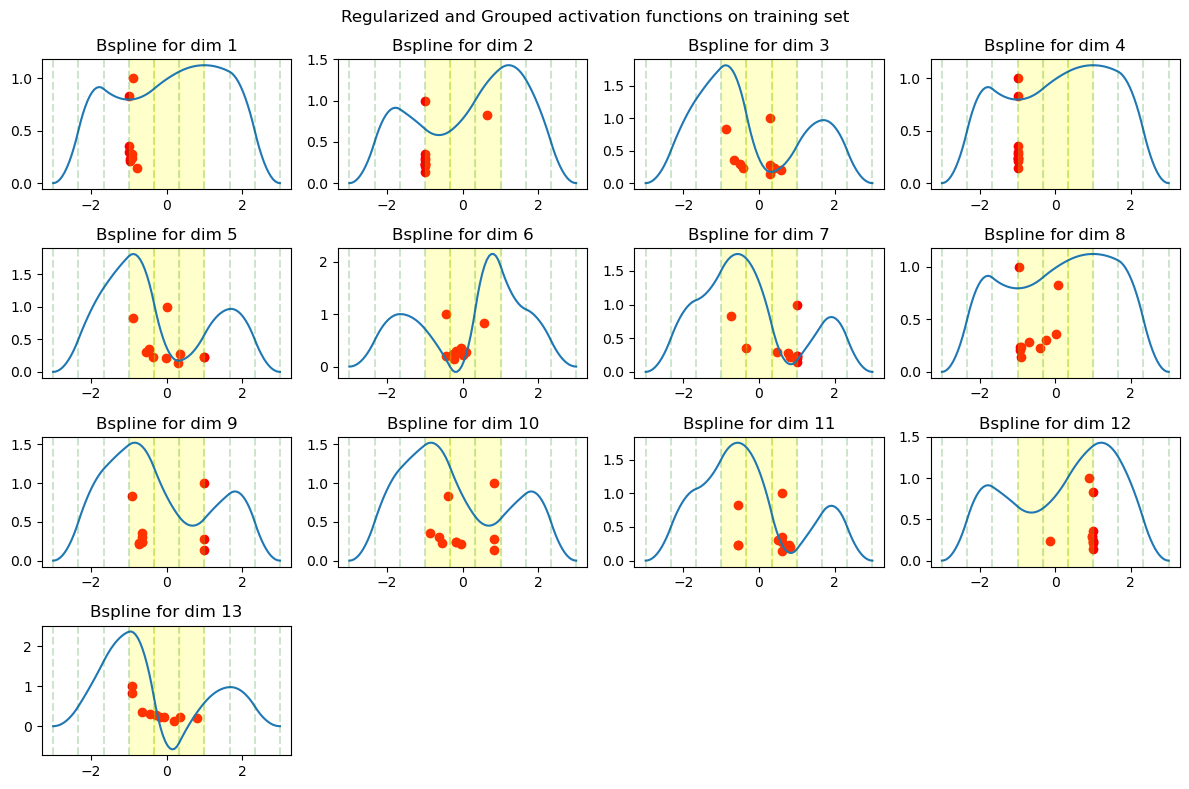

In [660]:
plot_x = np.linspace(layer.grid[0], layer.grid[-1], 100)
num_plots = len(layer.act_func)

# Determine the grid size, you can adjust rows and cols depending on how you want to layout the grid
rows = int(np.ceil(np.sqrt(num_plots)))
cols = int(np.ceil(num_plots / rows))

fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
axes = axes.flatten() 


for i in range(len(layer.act_func)):
    plot_y = np.dot(layer.spline_weights[i], layer.act_func[i](plot_x))

    axes[i].plot(plot_x, plot_y)
    axes[i].scatter(x_train[:10, i], y_train[:10], c='r')
    for x in layer.grid:
        axes[i].axvline(x, c='g', linestyle='--', alpha=0.2)
    
    axes[i].axvspan(layer.grid[3], layer.grid[4], color='yellow', alpha=0.2)
    axes[i].axvspan(layer.grid[4], layer.grid[5], color='yellow', alpha=0.2)
    axes[i].axvspan(layer.grid[5], layer.grid[6], color='yellow', alpha=0.2)
    axes[i].set_title(f'Bspline for dim {i+1}')

    
for j in range(i + 1, rows * cols):
    axes[j].axis('off')

fig.suptitle('Regularized and Grouped activation functions on training set')
plt.tight_layout()
plt.show()

In [661]:
train_loss = mse_loss(y_train[:100], layer.forward(x_train[:100]).squeeze())
val_loss = mse_loss(y_train[100:], layer.forward(x_train[100:]).squeeze())
print(f"The MSE Loss on training set is {train_loss}. The MSE Loss on validation set is {val_loss}.")

The MSE Loss on training set is 0.018910998478531837. The MSE Loss on validation set is 0.021999569609761238.


# Chapter 3: Efficient KAN

In [954]:
class Efficient_Spline:
    def __init__(self, knots, order):

        self.order = order
        self.knots = knots
        self.start = knots[0]
        self.width = knots[1] - knots[0]
        self.num_functions = len(knots) - order
        self.spline_weight = np.ones((self.num_functions))

    def recursive_function(self, k, t):
        if k == 1:
            return (t >= self.start) & (t < (self.start + self.width))

        a = (t - self.start) / ((k-1) * self.width)
        
        return (a * self.recursive_function(k-1, t)) \
                + ((k/(k-1)) - a) * self.recursive_function(k-1, t - self.width)

    def b_spline(self, t):
        t = np.tile(t[:,np.newaxis], (1,7))
        t = t - np.arange(self.num_functions) * self.width
        return self.recursive_function(self.order, t)


    def set_spline_weight(self, spline_weights):
        self.spline_weight = spline_weights

    def forward(self, t):
        return np.dot(self.b_spline(t), self.spline_weight)


In [955]:
k = 3
grid_start = 0
grid_end = 3
grid_size = 3
grid = np.arange(-k, grid_size + k + 1) + grid_start
print(f"this is the original grid: {grid}")

"""
k = 3 # the order spline we want
grid_size = 5 # number of control points
grid_start = 0 # start of range for our interpolation
grid_end = 3 # end of range for our interpolation
h = (grid_end - grid_start) / grid_size
augmented_grid = np.arange(-k, grid_size + k + 1) * h + grid_start
print(f"grid after augmenting the endpoints: {augmented_grid}")
""";

this is the original grid: [-3 -2 -1  0  1  2  3  4  5  6]


In [956]:
eff_spline = Efficient_Spline(grid, k)

In [957]:
def residuals(params, x, y):
    eff_spline.set_spline_weight(params)
    return y - eff_spline.forward(x)

In [958]:
initial_guess = np.ones(len(grid) - k)
fitted_params = scipy.optimize.least_squares(residuals, initial_guess, args = (x[:-1], y[:-1])).x

In [959]:
eff_spline.set_spline_weight(fitted_params)

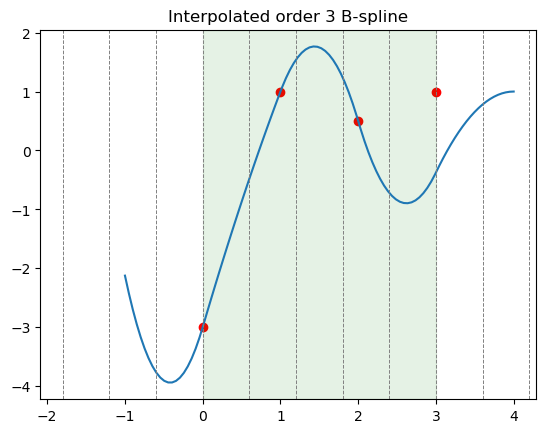

In [960]:
plot_x = np.linspace(-1, 4, 100)
plot_y = eff_spline.forward(plot_x)
plt.plot(plot_x, plot_y)
plt.scatter(x, y, c='r')

for vl in augmented_grid:
    plt.axvline(x=vl, color='gray', linestyle='--', linewidth=0.7)

plt.autoscale(False)
plt.fill_betweenx(y=plt.ylim(), x1=0, x2=3, color='green', alpha=0.1)
plt.title(f'Interpolated order {k} B-spline');

# Chapter 3.5: An Efficient Matrix Version of B-spline

In [757]:
x = np.array([0, 0.6, 1, 2, 3])
y = np.array([-3, -3.5, 1, 0.5, 1])

In [758]:
grid_size = 5
k = 3
# we are using a order 4 bspline with 5 intervals to interpolate
h = (grid_end - grid_start) / grid_size
augmented_grid = np.arange(-k, grid_size + k + 1) * h + grid_start

In [759]:
augmented_grid

array([-1.8, -1.2, -0.6,  0. ,  0.6,  1.2,  1.8,  2.4,  3. ,  3.6,  4.2,
        4.8])

In [760]:
N_2 = np.array([[9/2, -3*h, (h**2)/2], [-3/2, 3*h, -(h**2)], [0, 0, (h**2)/2]])

In [761]:
xi = x[1]
xi

0.6

In [762]:
N_2.T

array([[ 4.5 , -1.5 ,  0.  ],
       [-1.8 ,  1.8 ,  0.  ],
       [ 0.18, -0.36,  0.18]])

In [763]:
test = np.power((xi - np.arange(-k, grid_size+1) * h)[:, np.newaxis], np.arange(k))

In [764]:
test

array([[ 1.  ,  2.4 ,  5.76],
       [ 1.  ,  1.8 ,  3.24],
       [ 1.  ,  1.2 ,  1.44],
       [ 1.  ,  0.6 ,  0.36],
       [ 1.  ,  0.  ,  0.  ],
       [ 1.  , -0.6 ,  0.36],
       [ 1.  , -1.2 ,  1.44],
       [ 1.  , -1.8 ,  3.24],
       [ 1.  , -2.4 ,  5.76]])

In [765]:
np.dot(test, N_2.T)

array([[ 1.2168,  0.7464,  1.0368],
       [ 1.8432,  0.5736,  0.5832],
       [ 2.5992,  0.1416,  0.2592],
       [ 3.4848, -0.5496,  0.0648],
       [ 4.5   , -1.5   ,  0.    ],
       [ 5.6448, -2.7096,  0.0648],
       [ 6.9192, -4.1784,  0.2592],
       [ 8.3232, -5.9064,  0.5832],
       [ 9.8568, -7.8936,  1.0368]])

In [766]:
# order 3 b-spline
import math
def fast_bspline(grid):
    h = grid[1] - grid[0]
    k=3
    grid_size=5
    kh = 1/h
    N_2 = np.array([[9/2, -3*kh, (kh**2)/2], [-3/2, 3*kh, -(kh**2)], [0, 0, (kh**2)/2]])
    
    def fbspline(xs, params):
        results = []
        for xt in xs:
            selection_vector = (xt >= grid[:-k]) & (xt < grid[k:])
            par = params[selection_vector]
            x_augmented = xt - np.arange(-k, grid_size + 1) * h
            xt = np.power(x_augmented[selection_vector][:, np.newaxis], np.arange(k))
            results.append(np.sum(np.dot((N_2 * xt).T, par)))
            
        return results
    return fbspline

In [773]:
def objective_function_builder(x, y):
    def residuals(params):
        return np.sqrt(np.sum((y - fbs(x, params)) ** 2))


    return residuals

In [774]:
fbs = fast_bspline(augmented_grid)

In [775]:
initial_guess = np.zeros(k + grid_size + 1)
fitted_params = scipy.optimize.minimize(objective_function_builder(x[:-1], y[:-1]), 
                                       initial_guess,
                                       options={'disp':True,
                                               'maxiter':10}).x

         Current function value: 0.054040
         Iterations: 10
         Function evaluations: 140
         Gradient evaluations: 14


/opt/anaconda3/envs/mfml/lib/python3.11/site-packages/scipy/optimize/_minimize.py:726: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


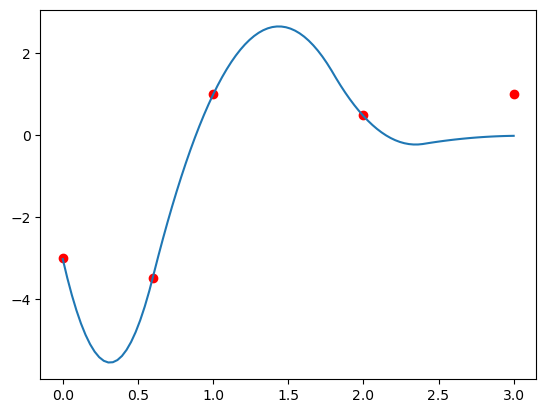

In [776]:
plot_x = np.linspace(0, 3, 100)
plot_y = fbs(plot_x, fitted_params)
plt.plot(plot_x, plot_y)
plt.scatter(x, y, c='r')

In [1662]:
augmented_grid

array([-1.8, -1.2, -0.6,  0. ,  0.6,  1.2,  1.8,  2.4,  3. ,  3.6,  4.2,
        4.8])

In [1773]:
xi = 0

In [1774]:
(xi - np.arange(-k, grid_size + 1) * h) # if we were using the basis function starting at 0, where x would be

array([ 1.8,  1.2,  0.6,  0. , -0.6, -1.2, -1.8, -2.4, -3. ])

In [1748]:
x_augmented = (xi - np.arange(-k, grid_size + 1) * h)
x_augmented#[(x_augmented * selection_vector) != 0]

array([ 1.8,  1.2,  0.6,  0. , -0.6, -1.2, -1.8, -2.4, -3. ])

In [1749]:
x_augmented[selection_vector]

array([1.2, 0.6, 0. ])

In [1716]:
func_1(1.35) + func_2(0.75) + func_3(0.15)

1.0000000000000002

In [1691]:
k = 3
grid_size=5
h = 0.6
kh = 1/h

In [1692]:
N_2 = np.array([[9/2, -3*kh, (kh**2)/2], [-3/2, 3*kh, -(kh**2)], [0, 0, (kh**2)/2]])

In [1695]:
N_2 * np.power(x_augmented[(x_augmented * selection_vector) != 0][:, np.newaxis], np.arange(k))

array([[ 4.5       , -8.        ,  3.55555556],
       [-1.5       ,  5.        , -2.77777778],
       [ 0.        ,  0.        ,  0.22222222]])

In [275]:
selection_vector = (xi >= augmented_grid[:-k]) & (xi < augmented_grid[k:]) # select the 2, 3, and 4 basis functions
selection_vector

array([False, False,  True,  True,  True, False, False, False, False])

In [1665]:
params = np.ones(k + grid_size + 1)
params

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [1666]:
params[(params * selection_vector) != 0] # weights of each basis function

array([1., 1., 1.])

In [1473]:
N_2 # top row is the coefficients for leftmost basis function
# middle row is coefficients for middle basis function
# bottom row is coefficients for rightmost basis function

array([[ 4.5 , -1.8 ,  0.18],
       [-1.5 ,  1.8 , -0.36],
       [ 0.  ,  0.  ,  0.18]])

In [1474]:
xi = 1
np.power((xi - np.arange(k-1, k+2) * h)[:,np.newaxis], np.arange(3))

array([[ 1.  , -0.2 ,  0.04],
       [ 1.  , -0.8 ,  0.64],
       [ 1.  , -1.4 ,  1.96]])

In [1475]:
x1 = xi - (k-1) * h
x2 = x1 - h
x3 = x2 - h
(x1, x2, x3)

(-0.19999999999999996, -0.7999999999999999, -1.4)

In [1476]:
xs = np.array([[1, x1, x1**2], [1, x2, x2**2], [1, x3, x3**2]])

In [1775]:
k = 3
h = 0.6
kh = 1/h

In [1784]:
func_1 = lambda x: (9/2) - 3*kh*x + (kh**2/2)*x**2
func_2 = lambda x: -3/2 + 3*kh*x - (kh**2)*x**2
func_3 = lambda x: (kh**2)/2*x**2

func_4 = lambda x: (9/2) - 3*kh*(x-0.6) + (kh**2/2)*(x-0.6)**2
func_5 = lambda x: -3/2 + 3*kh*(x-0.6) - (kh**2)*(x-0.6)**2
func_6 = lambda x: (kh**2)/2*(x-0.6)**2

func_7 = lambda x: (9/2) - 3*kh*(x-1.2) + (kh**2/2)*(x-1.2)**2
func_8 = lambda x: -3/2 + 3*kh*(x-1.2) - (kh**2)*(x-1.2)**2
func_9 = lambda x: (kh**2)/2*(x-1.2)**2

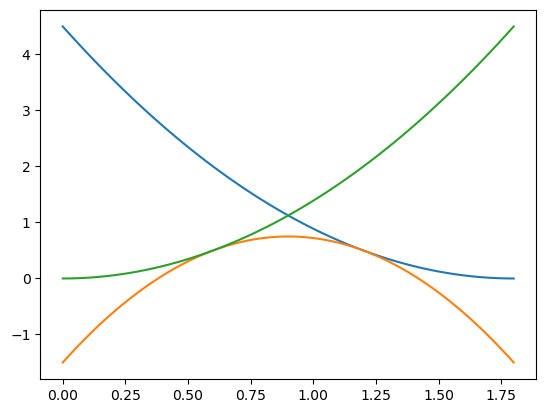

In [1777]:
plot_x = np.linspace(0, 1.8, 100)
plot_y1 = func_1(plot_x)
plot_y2 = func_2(plot_x)
plot_y3 = func_3(plot_x)
plt.plot(plot_x, plot_y1)
plt.plot(plot_x, plot_y2)
plt.plot(plot_x, plot_y3)

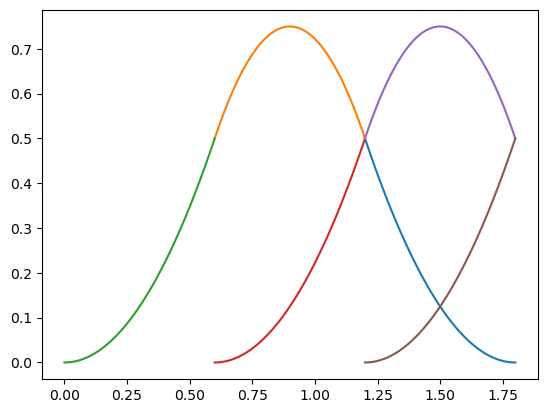

In [1786]:

plot_x3 = np.linspace(0, h, 100)
plot_x2 = np.linspace(h, 2 * h, 100)
plot_x1 = np.linspace(2 * h, 3 * h, 100)


plot_y1 = func_1(plot_x1)
plot_y2 = func_2(plot_x2)
plot_y3 = func_3(plot_x3)


plt.plot(plot_x1, plot_y1)
plt.plot(plot_x2, plot_y2)
plt.plot(plot_x3, plot_y3)


plt.plot(plot_x2, func_6(plot_x2))
plt.plot(plot_x1, func_5(plot_x1))

plt.plot(plot_x1, func_9(plot_x1))

#xi = 1.6
#plt.scatter(1.6, func_1(1.6), c='r')

In [1649]:
k = 3
h = 0.6
kh = 1/h

In [1650]:
kh

1.6666666666666667

In [1652]:
func_1 = lambda x: (9/2) - 3*kh*(x-1.8) + (kh**2/2)*(x-1.8)**2
func_2 = lambda x: -3/2 + 3*kh*(x-1.8) - (kh**2)*(x-1.8)**2
func_3 = lambda x: (kh**2)/2*(x-1.8)**2

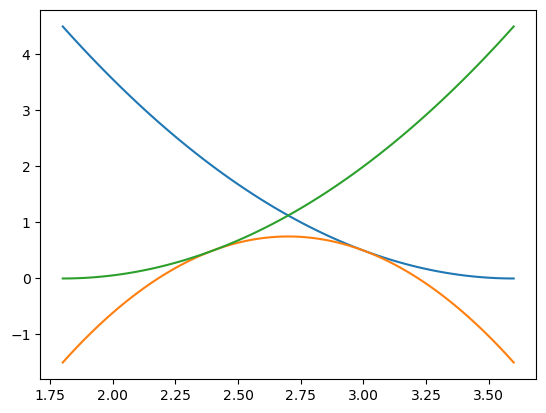

In [1654]:
plot_x = np.linspace(0, 1.8, 100) +1.8
plot_y1 = func_1(plot_x)
plot_y2 = func_2(plot_x)
plot_y3 = func_3(plot_x)
plt.plot(plot_x, plot_y1)
plt.plot(plot_x, plot_y2)
plt.plot(plot_x, plot_y3)

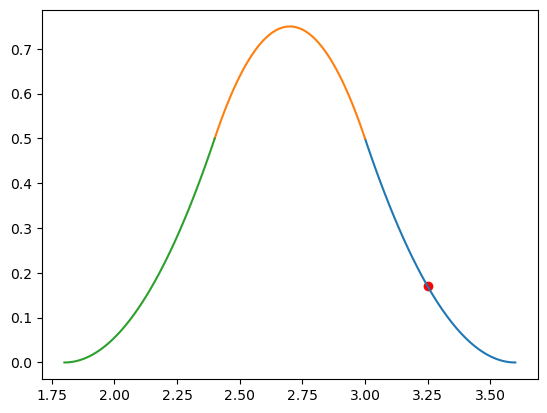

In [1656]:
plot_x3 = np.linspace(1.8, 1.8 + h, 100)
plot_x2 = np.linspace(1.8 + h, 1.8 + 2*h, 100)
plot_x1 = np.linspace(1.8 + 2*h, 1.8 + 3*h, 100)


plot_y1 = func_1(plot_x1)
plot_y2 = func_2(plot_x2)
plot_y3 = func_3(plot_x3)


plt.plot(plot_x1, plot_y1)
plt.plot(plot_x2, plot_y2)
plt.plot(plot_x3, plot_y3)

xi = 3.25
plt.scatter(3.25, func_1(3.25), c='r')

# Chapter 4: KAN Matrix

In [365]:
x_train[:,:,np.newaxis].shape

(404, 13, 1)

In [295]:
(x_train.flatten().reshape((-1, 1)) - np.arange(-3, 6) * 0.2).reshape((404, 13, -1)).shape

(404, 13, 9)

In [302]:
(-3 + selection_vector) * 0.2

array([[-0.4, -0.4, -0.4, ..., -0.2, -0.2, -0.4],
       [-0.4, -0.2, -0.4, ..., -0.4, -0.2, -0.4],
       [-0.4, -0.4, -0.2, ..., -0.2, -0.2, -0.4],
       ...,
       [-0.4, -0.4, -0.4, ..., -0.4, -0.2, -0.4],
       [-0.4, -0.4, -0.2, ..., -0.4, -0.2, -0.4],
       [-0.4, -0.2, -0.4, ..., -0.4, -0.2, -0.4]])

In [304]:
(x_train - (-3 + selection_vector) * 0.2).shape

(404, 13)

In [ ]:
x[dim] - np.arange(-self.spline_order, self.grid_size + 1) * self.grid_width

In [200]:
x_train[:,:,np.newaxis].shape

(404, 13, 1)

In [298]:
selection_vector = np.argmax((x_train[:,:,np.newaxis] >= augmented_grid[:-3]) & (x_train[:,:,np.newaxis] < augmented_grid[3:]), axis=2)

In [285]:
selection_vector = selection_vector[:,:,None] + np.arange(3)
selection_vector.shape

(404, 13, 3)

In [286]:
testclass.spline_weights.shape, selection_vector.shape

((13, 1, 9), (404, 13, 3))

In [287]:
testclass.spline_weights[np.arange(13)[:,None], :, selection_vector.T].shape

(3, 13, 404, 1)

In [265]:
result = testclass.spline_weights[np.arange(13)[:, None], :, selection_vector.T]

In [277]:
result.transpose(1, 0, 2).shape

(404, 13, 1)

In [326]:
testclass.spline_weights.shape

(13, 1, 9)

In [327]:
selection_vector.shape

(404, 13)

In [283]:
for num in range(404):
    for dim in range(13):
        print(testclass.spline_weights[dim][:,selection_vector[num][dim]:selection_vector[num][dim] + 3])

[[-0.44970276 -1.13202442  0.81758648]]
[[-0.48592577 -0.63120269  0.82214928]]
[[0.86141282 0.01572774 0.0939649 ]]
[[-0.85729393 -0.85729393  1.        ]]
[[ 0.82180787  0.06915398 -0.11385143]]
[[1.         0.95540943 0.24020141]]
[[0.96918508 0.72667932 0.46781126]]
[[ 0.68026853 -0.40288154 -0.01845487]]
[[ 0.74278785 -0.76397903  0.28603711]]
[[ 0.81759999 -0.09353904 -0.01969343]]
[[0.97690926 0.76573364 0.45090855]]
[[0.92272718 0.77177525 0.86798388]]
[[ 0.79374647 -0.06557148 -0.15911897]]
[[-0.44970276 -1.13202442  0.81758648]]
[[-0.63120269  0.82214928  0.84130381]]
[[0.86141282 0.01572774 0.0939649 ]]
[[-0.85729393 -0.85729393  1.        ]]
[[ 0.82180787  0.06915398 -0.11385143]]
[[1.         0.95540943 0.24020141]]
[[0.96918508 0.72667932 0.46781126]]
[[ 0.68026853 -0.40288154 -0.01845487]]
[[ 0.74278785 -0.76397903  0.28603711]]
[[ 0.81759999 -0.09353904 -0.01969343]]
[[0.97690926 0.76573364 0.45090855]]
[[0.92272718 0.77177525 0.86798388]]
[[ 0.79374647 -0.06557148 -0.1

IndexError: index 13 is out of bounds for axis 0 with size 13

In [334]:
class KAN:
    def __init__(self, dim_in, dim_out, spline_order, grid_size, grid_range):
        self.dim_out = dim_out
        self.dim_in = dim_in
        self.spline_order = 3 # only support order 3 bsplines currently
        self.grid_size = grid_size
        self.grid_width = (grid_range[1] - grid_range[0]) / grid_size
        kh = 1 / self.grid_width
        #self.basis_matrix = np.array([[9/2, -3*kh, (kh**2)/2], [-3/2, 3*kh, -(kh**2)], [0, 0, (kh**2)/2]])
        self.basis_matrix = np.array([[9/2, -3*kh, (kh**2)/2], [-11/2, 5*kh, -(kh**2)], [2, -2*kh, (kh**2)/2]])
        self.spline_weights = np.ones((self.dim_in, self.dim_out, spline_order + grid_size + 1))
        #self.spline_weights = np.ones(spline_order + grid_size + 1)
        self.grid = np.arange(-spline_order, grid_size + spline_order + 1) * self.grid_width + grid_range[0]

    def load_weights(self, new_spline_weights):
        self.spline_weights = new_spline_weights.reshape((self.dim_in, self.dim_out, self.spline_order + self.grid_size + 1))
        #self.spline_weights = new_spline_weights

    def view_bspline(self, xs, i):
        # only take single x inputs

        result = []
        spline_weight = self.spline_weights[i][0]
        for x in xs:
            selection_vector = np.argmax((x >= self.grid[:-self.spline_order]) & (x < self.grid[self.spline_order:]))
            
    
            weights = spline_weight[selection_vector:selection_vector+3]
            x_augmented = x - np.arange(-self.spline_order, self.grid_size + 1) * self.grid_width
            x = np.power(x_augmented[selection_vector], np.arange(self.spline_order)) 

            result.append(np.dot(weights, np.dot(self.basis_matrix, x.T)))
    
            #result.append(np.dot(weights, np.sum(self.basis_matrix * x, axis=1)))

        return result


        """
        
        result = []
        spline_weight = self.spline_weights[i][0]
        for x in xs:
            selection_vector = (x >= self.grid[:-self.spline_order]) & (x < self.grid[self.spline_order:])
    
            weights = spline_weight[selection_vector]
            x_augmented = x - np.arange(-self.spline_order, self.grid_size + 1) * self.grid_width
            x = np.power(x_augmented[selection_vector].reshape(self.spline_order, 1), np.arange(self.spline_order))  
    
            result.append(np.dot(weights, np.sum(self.basis_matrix * x, axis=1)))

        return result
        """


    def forward(self, x):


        # bs x di
        selection_vector = np.argmax((x[:,:,np.newaxis] >= self.grid[:-self.spline_order]) & (x[:,:,np.newaxis] < self.grid[self.spline_order:]), axis=2)
        x_augmented = x - (-self.spline_order + selection_vector) * self.grid_width # bs x di
        x_augmented = x_augmented.reshape(-1, 1) ** np.arange(self.spline_order) # bs*di x so
        
        selection_vector = selection_vector[:,:,None] + np.arange(3)
        spline_weights = self.spline_weights[np.arange(self.dim_in)[:,None], :, selection_vector.T].transpose(3, 0, 2, 1) # do x so x bs x di

        # np.dot(self.basis_matrix, x_augmented.T) # so x bs*di 
        # spline_weights.reshape((self.dim_out, -1)) # do x so*bs*di
        
        return np.dot(spline_weights.reshape((self.dim_out, -1)), np.dot(self.basis_matrix, x_augmented.T).flatten()) # do x 1
        
        
        """
        result = []
        for dim in range(len(x)):
            selection_vector = np.argmax((x[dim] >= self.grid[:-self.spline_order]) & (x[dim] < self.grid[self.spline_order:]))
            par = self.spline_weights[dim][:,selection_vector:selection_vector+3] # 3 x 3
            x_augmented = x[dim] - np.arange(-self.spline_order, self.grid_size + 1) * self.grid_width
            x_augmented = np.power(x_augmented[selection_vector], np.arange(self.spline_order)) # 1 x 3

            result.append(np.dot(par, np.dot(self.basis_matrix, x_augmented.T))) # 3x1
            #result.append(np.dot(par, np.sum(self.basis_matrix * x_augmented, axis=1)))
   
        return np.sum(result)
        """



        """
        result = []
        for dim in range(len(x)):
            selection_vector = (x[dim] >= self.grid[:-self.spline_order]) & (x[dim] < self.grid[self.spline_order:])
            par = self.spline_weights[dim][:,selection_vector] # 1 x 3
            x_augmented = x[dim] - np.arange(-self.spline_order, self.grid_size + 1) * self.grid_width
            x_augmented = np.power(x_augmented[selection_vector][:, np.newaxis], np.arange(self.spline_order)) # 3 x 3

            result.append(np.dot(par, np.sum(self.basis_matrix * x_augmented, axis=1)))
   
        return np.sum(result)
        """


        """
        selection_vector = (x >= self.grid[:-self.spline_order]) & (x < self.grid[self.spline_order:])
        par = self.spline_weights[selection_vector]
        x_augmented = x - np.arange(-self.spline_order, self.grid_size + 1) * self.grid_width
        x = np.power(x_augmented[selection_vector][:, np.newaxis], np.arange(self.spline_order))
        return np.sum(np.dot((self.basis_matrix * x).T, par))
        """
        

In [350]:
testclass = KAN(1, 2, spline_order=3, grid_size=5, grid_range=[0, 1])

In [351]:
def objective_function_builder(kan, x, y):
    def residuals(params):
        kan.load_weights(params)
        print(kan.spline_weights)
        return np.sqrt(np.sum((y - kan.forward(x)) ** 2))
        #return np.sqrt(np.sum([(y[i] - kan.forward(x[i])) ** 2 for i in range(len(x))]))

    return residuals

def loop_it(x):
    result = []
    for xs in x:
        result.append(testclass.forward(xs))
    return np.array(result)

In [355]:
xn = np.array([[0], [0.15], [0.75], [0.99]])
yn = np.array([[0.4, 0.3], [0.1, 0.3], [3, 1], [-3.5, 0.9]])

In [356]:
initial_guess = np.ones(18)
"""
fitted_weights = scipy.optimize.minimize(objective_function_builder(testclass, x_train[:100], y_train[:100]),
                                        initial_guess,
                                        options={'maxiter':1}).x

"""
fitted_weights = scipy.optimize.minimize(objective_function_builder(testclass, xn, yn), initial_guess,
                                                                    options={'dist':True, 'maxiter':10}).x


[[[1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1.]]]
[[[1.00000001 1.         1.         1.         1.         1.
   1.         1.         1.        ]
  [1.         1.         1.         1.         1.         1.
   1.         1.         1.        ]]]
[[[1.         1.00000001 1.         1.         1.         1.
   1.         1.         1.        ]
  [1.         1.         1.         1.         1.         1.
   1.         1.         1.        ]]]
[[[1.         1.         1.00000001 1.         1.         1.
   1.         1.         1.        ]
  [1.         1.         1.         1.         1.         1.
   1.         1.         1.        ]]]
[[[1.         1.         1.         1.00000001 1.         1.
   1.         1.         1.        ]
  [1.         1.         1.         1.         1.         1.
   1.         1.         1.        ]]]
[[[1.         1.         1.         1.         1.00000001 1.
   1.         1.         1.        ]
  [1.         1.         1.         1.        

/var/folders/_s/2yjncdv10_3286fg9ws6kq5w0000gn/T/ipykernel_1597/3483533456.py:8: OptimizeWarning: Unknown solver options: dist
  fitted_weights = scipy.optimize.minimize(objective_function_builder(testclass, xn, yn), initial_guess,


In [357]:
testclass.load_weights(fitted_weights)

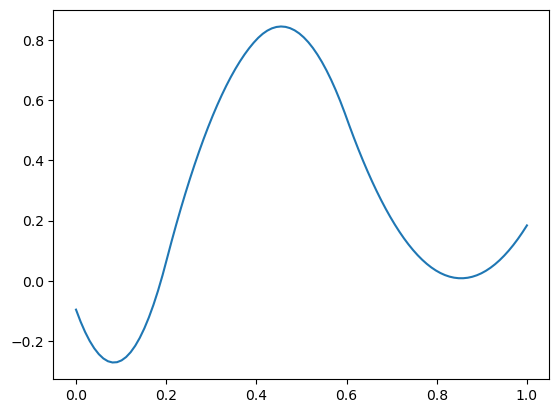

In [363]:
plot_x = np.linspace(0, 1, 100)
plot_y = testclass.view_bspline(plot_x, 0)
#plot_y = loop_it(plot_x)

plt.plot(plot_x, plot_y)
#plt.scatter(x_train[:100][:,0], y_train[:100], c='r')

In [189]:
from scipy.linalg import block_diag

In [1231]:
x[:-1]

array([0, 1, 2])

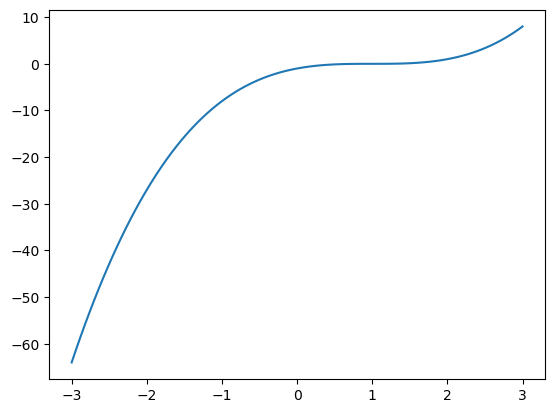

In [1245]:
func = lambda x: -1 + 3*x**1 - 3*x**2 + x**3
plot_x = np.linspace(-3, 3, 100)
plot_y = func(plot_x)
plt.plot(plot_x, plot_y)

In [1206]:
M = np.array([[-1,  3       , -3      ,  1],
       [ 3       , -6       ,  3       ,  0        ],
       [-3       ,  0       ,  3       ,  0       ],
       [ 1,  4,  1,  0     ]])
M = (1/6) * M

In [1232]:
M = np.array([[1,  1       , 0],
       [ -2       , 2       ,  0],
       [1       ,  -2       ,  1]])
M = (1/2) * M

In [1233]:
grid_size = 5
k = 3
# we are using a order 4 bspline with 5 intervals to interpolate
h = (grid_end - grid_start) / grid_size
augmented_grid = np.arange(-k, grid_size + k + 1) * h + grid_start

In [1234]:
augmented_grid

array([-1.8, -1.2, -0.6,  0. ,  0.6,  1.2,  1.8,  2.4,  3. ,  3.6,  4.2,
        4.8])

In [1235]:
M_full = block_diag(*[M]*grid_size)

In [1236]:
def relu_sigmoid(x):
    # Apply the sigmoid function to positive values, and set negative values to 0
    return np.where(x > 0, 1 / (1 + np.exp(-x)), 0)

def relu(x):
    return np.where(x > 0, x, 0)

In [1239]:
def residuals(params, x, y):
    # Constructing the desired array by using slicing
    params = np.concatenate([
        params[0:4],   # w1, w2, w3, w4
        params[1:5],   # w2, w3, w4, w5
        params[2:6],   # w3, w4, w5, w6
        params[3:7],   # w4, w5, w6, w7
        params[4:8]    # w5, w6, w7, w8
    ])

    params = np.concatenate([
        params[0:3],   # w1, w2, w3, w4
        params[1:4],   # w2, w3, w4, w5
        params[2:5],   # w3, w4, w5, w6
        params[3:6],   # w4, w5, w6, w7
        params[4:7]    # w5, w6, w7, w8
    ])

    #new_x = []
    #for i in range(grid_size):
    #    new_x.append((x - augmented_grid[k + i]) / (augmented_grid[k + i + 1] - augmented_grid[k + i]))

    #print(new_x)
    #x = np.array(new_x).reshape((3, 5))
    #print(x.shape)
    """
    new_x = []
    for i in range(len(x)):
        new_x.append([[j**3, j**2, j**1, 1] for j in x[i]])

    x = np.array(new_x).reshape((3, 20))
    """

    stacked_x = np.array([[1, xi, xi**2, xi**3] * grid_size for xi in x])
    stacked_x = np.array([[1, xi, xi**2] * grid_size for xi in x])
    
    #print(x.shape)
    return y - np.dot(stacked_x, np.dot(M_full, params))

In [1240]:
initial_guess = np.ones(grid_size + k - 1)
fitted_params = scipy.optimize.least_squares(residuals, initial_guess, args = (x[:-1], y[:-1])).x

In [1241]:
plot_x = np.linspace(-1, 4, 100)
temp_x = np.array([[1, xi, xi**2, xi**3] * 5 for xi in plot_x])
temp_x = np.array([[1, xi, xi**2] * grid_size for xi in plot_x])
"""
new_x = []
for i in range(grid_size):
    new_x.append((plot_x - augmented_grid[k + i]) / (augmented_grid[k + i + 1] - augmented_grid[k + i]))

temp_x = np.array(new_x).reshape((100, 5))
new_x = []
for i in range(len(temp_x)):
    new_x.append([[j**3, j**2, j**1, 1] for j in temp_x[i]])

temp_x = np.array(new_x).reshape((100, 20))
""";


In [1242]:
initial_guess = np.concatenate([
        fitted_params[0:4],   # w1, w2, w3, w4
        fitted_params[1:5],   # w2, w3, w4, w5
        fitted_params[2:6],   # w3, w4, w5, w6
        fitted_params[3:7],   # w4, w5, w6, w7
        fitted_params[4:8]    # w5, w6, w7, w8
    ])


initial_guess = np.concatenate([
        fitted_params[0:3],   # w1, w2, w3, w4
        fitted_params[1:4],   # w2, w3, w4, w5
        fitted_params[2:5],   # w3, w4, w5, w6
        fitted_params[3:6],   # w4, w5, w6, w7
        fitted_params[4:7]    # w5, w6, w7, w8
    ])

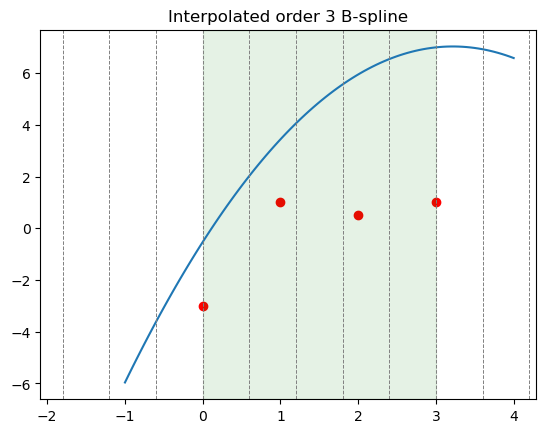

In [1243]:
plot_y = np.dot(temp_x,  np.dot(M_full, initial_guess))
plt.plot(plot_x, plot_y)
plt.scatter(x, y, c='r')

for vl in augmented_grid:
    plt.axvline(x=vl, color='gray', linestyle='--', linewidth=0.7)

plt.autoscale(False)
plt.fill_betweenx(y=plt.ylim(), x1=0, x2=3, color='green', alpha=0.1)
plt.title(f'Interpolated order {k} B-spline');

In [1037]:
fitted_params = scipy.optimize.least_squares(residuals, fitted_params, args = (x, y)).x

In [1038]:
plot_x = np.linspace(-1, 4, 100)
stacked_x = np.array([[1, xi, xi**2, xi**3] * 5 for xi in plot_x])
stacked_x.shape

(100, 20)

In [1039]:
initial_guess = np.concatenate([
        fitted_params[0:4],   # w1, w2, w3, w4
        fitted_params[1:5],   # w2, w3, w4, w5
        fitted_params[2:6],   # w3, w4, w5, w6
        fitted_params[3:7],   # w4, w5, w6, w7
        fitted_params[4:8]    # w5, w6, w7, w8
    ])

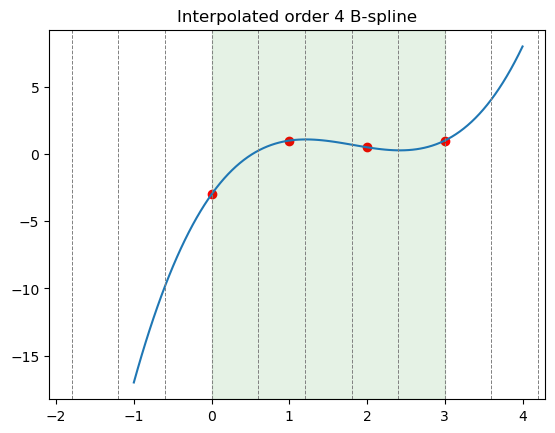

In [1040]:
plot_y = np.dot(stacked_x,  np.dot(M_full, initial_guess))
plt.plot(plot_x, plot_y)
plt.scatter(x, y, c='r')

for vl in augmented_grid:
    plt.axvline(x=vl, color='gray', linestyle='--', linewidth=0.7)

plt.autoscale(False)
plt.fill_betweenx(y=plt.ylim(), x1=0, x2=3, color='green', alpha=0.1)
plt.title(f'Interpolated order {k} B-spline');

In [1042]:
k=4
grid_size=5
h = (grid_end - grid_start) / grid_size
augmented_grid = np.arange(-k, grid_size + k + 1) * h + grid_start
print(f"grid after augmenting the endpoints: {augmented_grid}")
matrix_bspline = b_spline(augmented_grid, k)

grid after augmenting the endpoints: [-2.4 -1.8 -1.2 -0.6  0.   0.6  1.2  1.8  2.4  3.   3.6  4.2  4.8  5.4]


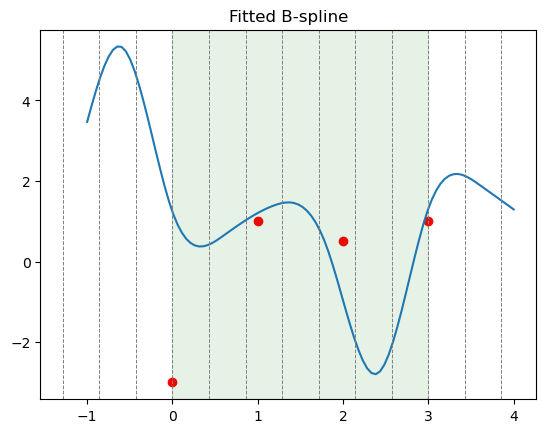

In [1049]:
plot_x = np.linspace(-1, 4, 100)
plot_y = np.dot(np.concatenate(([1], fitted_params, [1])), matrix_bspline(plot_x))
plt.plot(plot_x, plot_y)
plt.scatter(x, y, c='r')

for vl in augmented_grid_fine:
    plt.axvline(x=vl, color='gray', linestyle='--', linewidth=0.7)

plt.autoscale(False)
plt.fill_betweenx(y=plt.ylim(), x1=0, x2=3, color='green', alpha=0.1)

plt.title('Fitted B-spline');

# Chapter 3: The Convolutional KAN

# Chapter 4: Spkan - Sparse Convolutions with Kolmogorov-Arnold Networks